In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow" # <--- ¡Añade esta línea aquí!
import shutil
import time
from google.colab import drive

print("--- COPIANDO CARPETAS ESPECÍFICAS DE DRIVE A LA UNIDAD LOCAL DE COLAB ---")

# Montar Google Drive (solo se hace una vez al inicio de la sesión de Colab)
drive.mount('/content/drive')
print("Google Drive montado con éxito.")

# Define las rutas raíz
SOURCE_PROJECT_ROOT = "/content/drive/MyDrive/Proyecto_Final_Upgrade/"
LOCAL_PROJECT_ROOT = "/content/Proyecto_Final_Upgrade/"

# Lista de las subcarpetas a copiar
# Asegúrate de que los nombres de las carpetas coincidan exactamente con las de tu Drive
folders_to_copy = [
    "test_images/",
    "models/",
    "Datos_YOLO/Emotions/"
]

total_start_time = time.time()
for folder_name in folders_to_copy:
    source_path = os.path.join(SOURCE_PROJECT_ROOT, folder_name)
    local_path = os.path.join(LOCAL_PROJECT_ROOT, folder_name)

    print(f"\nIntentando copiar: '{folder_name}' de '{source_path}' a '{local_path}'")

    # Crea el directorio de destino si no existe.
    # 'exist_ok=True' evita un error si el directorio ya existe.
    os.makedirs(local_path, exist_ok=True)
    print(f"Directorio local de destino asegurado para '{folder_name.rstrip('/')}': {local_path}")

    start_time_folder = time.time()
    try:
        # shutil.copytree es ideal para copiar directorios completos y su contenido recursivamente.
        # 'dirs_exist_ok=True' es importante para evitar errores si la carpeta de destino ya existe
        # y solo quieres sincronizar o añadir contenido.
        shutil.copytree(source_path, local_path, dirs_exist_ok=True)
        end_time_folder = time.time()
        print(f"Carpeta '{folder_name.rstrip('/')}' copiada con éxito en {end_time_folder - start_time_folder:.2f} segundos.")
    except FileNotFoundError:
        print(f"ADVERTENCIA: La carpeta de origen '{source_path}' NO EXISTE en Google Drive. Saltando la copia de esta carpeta.")
    except Exception as e:
        print(f"ERROR al copiar la carpeta '{folder_name.rstrip('/')}': {e}")
        print("Asegúrate de que la ruta de origen en Drive sea correcta y que haya suficiente espacio en la unidad local de Colab.")
        print("Puedes verificar el espacio disponible con: !df -h")

total_end_time = time.time()
print(f"\n--- Proceso de copia de todas las carpetas solicitadas completado en {total_end_time - total_start_time:.2f} segundos. ---")

--- COPIANDO CARPETAS ESPECÍFICAS DE DRIVE A LA UNIDAD LOCAL DE COLAB ---
Mounted at /content/drive
Google Drive montado con éxito.

Intentando copiar: 'test_images/' de '/content/drive/MyDrive/Proyecto_Final_Upgrade/test_images/' a '/content/Proyecto_Final_Upgrade/test_images/'
Directorio local de destino asegurado para 'test_images': /content/Proyecto_Final_Upgrade/test_images/
Carpeta 'test_images' copiada con éxito en 2.54 segundos.

Intentando copiar: 'models/' de '/content/drive/MyDrive/Proyecto_Final_Upgrade/models/' a '/content/Proyecto_Final_Upgrade/models/'
Directorio local de destino asegurado para 'models': /content/Proyecto_Final_Upgrade/models/
Carpeta 'models' copiada con éxito en 17.14 segundos.

Intentando copiar: 'Datos_YOLO/Emotions/' de '/content/drive/MyDrive/Proyecto_Final_Upgrade/Datos_YOLO/Emotions/' a '/content/Proyecto_Final_Upgrade/Datos_YOLO/Emotions/'
Directorio local de destino asegurado para 'Datos_YOLO/Emotions': /content/Proyecto_Final_Upgrade/Datos_YOL

In [ ]:
!python --version

Python 3.11.13


In [2]:
from google.colab import drive

print("Desmontando Google Drive...")
try:
    drive.flush_and_unmount()
    print("Google Drive desmontado exitosamente.")
except Exception as e:
    print(f"Error al desmontar Google Drive: {e}")
    print("Es posible que Drive no estuviera montado o que ya se haya desmontado.")

Desmontando Google Drive...
Google Drive desmontado exitosamente.


In [ ]:
# Celda 2: Instalaciones y Actualizaciones

print("Instalando y actualizando bibliotecas necesarias...")

try:
    # --- PASO CRÍTICO: DESINSTALAR VERSIONES EXISTENTES PARA EVITAR CONFLICTOS ---
    print("Desinstalando versiones existentes de TensorFlow, Keras y NumPy...")
    !pip uninstall -y tensorflow keras numpy

    # --- PASO 1: INSTALAR TENSORFLOW 2.15.0 ---
    # TensorFlow 2.15.0 traerá su propia versión compatible de NumPy y Keras (Keras 2.15.0).
    print("Instalando tensorflow==2.15.0...")
    !pip install tensorflow==2.15.0

    # --- PASO 2: INSTALAR/ACTUALIZAR KERAS ---
    # ESTA LÍNEA ES EL PROBLEMA. ¡LA ELIMINAMOS!
    # print("Instalando/actualizando keras a la última versión (Keras 3)...")
    # !pip install keras --upgrade

    # --- PASO 3: INSTALAR OTRAS LIBRERÍAS NECESARIAS ---
    print("Instalando otras bibliotecas...")
    !pip install opencv-python matplotlib scikit-learn ultralytics
    print("Actualizando Pillow para evitar errores de carga de imagen...")
    !pip install Pillow --upgrade

    print("Instalaciones y actualizaciones completadas.")

except Exception as e:
    print(f"Error durante las instalaciones/actualizaciones: {e}")
    print("Por favor, revisa el mensaje de error y asegúrate de que tu entorno esté configurado correctamente.")

Instalando y actualizando bibliotecas necesarias...
Desinstalando versiones existentes de TensorFlow, Keras y NumPy...
Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Instalando tensorflow==2.15.0...
  Using cached tensorflow-2.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.4 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached tensorflow-2.15.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (475.3 MB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_6

Instalando otras bibliotecas...
  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
^C
Actualizando Pillow para evitar errores de carga de imagen...


In [1]:
!pip install tensorflow==2.15.0

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.5.2 requires ml_dtypes>=0.4.0, but you have ml-dtypes 0.2.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorstore 0.1.74 requires ml_dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.18.0 requires t

In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import json
import math
import cv2 # Para manipulación de imágenes y video
from ultralytics import YOLO # Para el modelo YOLO de detección de caras
from typing import Tuple

# Para el modelo de emociones
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
# Para ImageDataGenerator, no usaremos el preprocessing_function directamente aquí para evitar doble escalado
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import preprocess_input # ¡NUEVA IMPORTACIÓN CLAVE!
# from google.colab.kernel import register_callback

# --- Configuración de path local y Rutas ---
LOCAL_BASE_PATH = "/content/Proyecto_Final_Upgrade"
DIRECTORIO_MODELOS_PERSISTENTE = os.path.join(LOCAL_BASE_PATH, 'models')

# La ruta a tus datos ahora incluye la carpeta 'Emotions'.
DIRECTORIO_DATOS = os.path.join(LOCAL_BASE_PATH, 'Datos_YOLO', 'Emotions')


# Rutas específicas para guardar modelos de cada fase
RUTA_MODELO_FASE1 = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'emotion_classifier_efficientnetb0_fase1_best.keras')
RUTA_MODELO_FASE2 = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'emotion_classifier_efficientnetb0_fase2_best.keras')
RUTA_HISTORY_FASE1 = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'training_history_fase1.npy')
RUTA_HISTORY_FASE2 = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'training_history_fase2.npy')

# --- NUEVAS RUTAS AÑADIDAS ---
RUTA_MODELO_FINAL = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'emotion_classifier_efficientnetb0_final_best.keras')
RUTA_HISTORY_FINAL = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'training_history_final.npy')


# Ruta para el modelo YOLO
RUTA_MODELO_YOLO_FINAL = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'yolov8n-face.pt')

# Ruta para los índices de emociones
RUTA_INDICES_EMOCIONES_FINAL = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'emotion_class_indices.json')


# --- Parámetros de Imagen para el Modelo de Emociones ---
IMG_WIDTH_EMO = 224
IMG_HEIGHT_EMO = 224
BATCH_SIZE_EMO = 32

# --- Parámetros de Entrenamiento para el Modelo de Emociones ---
# Estos serán definidos en el punto de los Callbacks para ser más específicos de cada fase

# Definición de las clases para YOLO (yolov8n-face.pt solo detecta 'face')
CLASES_YOLO_CARAS = {0: 'face'}

# --- Variables NUM_CLASSES_EMO y EMOTION_LABELS (Se actualizarán en la celda de preprocesamiento de datos) ---
NUM_CLASSES_EMO = 7 # Valor por defecto, se actualizará
EMOTION_LABELS = { # Para respaldo, se actualizará
    0: 'angry', 1: 'disgust', 2: 'fear',
    3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'
}

print("Configuración esencial cargada y variables globales inicializadas.")
print(f"Ruta base en path local: {LOCAL_BASE_PATH}")

# --- TRAZAS AÑADIDAS: Verificación del Entorno TensorFlow ---
print("\n--- Verificación del Entorno TensorFlow ---")
print(f"Versión de TensorFlow: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPUs detectadas: {gpu_devices}")
    for gpu in gpu_devices:
        # Esto es una buena práctica para GPUs, permite que TensorFlow use solo la memoria necesaria
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Crecimiento de memoria de GPU habilitado.")
else:
    print("¡ADVERTENCIA! No se detectaron GPUs. TensorFlow se ejecutará en CPU.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Configuración esencial cargada y variables globales inicializadas.
Ruta base en path local: /content/Proyecto_Final_Upgrade

--- Verificación del Entorno TensorFlow ---
Versión de TensorFlow: 2.15.0
¡ADVERTENCIA! No se detectaron GPUs. TensorFlow se ejecutará en CPU.


In [ ]:
# --- Celda 4: Preparación y Aumento de Datos para Emociones (Revisada y Optimizada) ---
print("\n--- PREPARACIÓN DE DATOS PARA CLASIFICADOR DE EMOCIONES ---")

# Asegúrate de que las importaciones necesarias para el cálculo de pesos estén en Celda 3 o aquí:
import numpy as np
from sklearn.utils import class_weight # Asegúrate de que sklearn.utils esté importado

if not os.path.exists(DIRECTORIO_DATOS):
    print(f"ERROR: El directorio de datos '{DIRECTORIO_DATOS}' no existe.")
    raise FileNotFoundError(f"Directorio de datos no encontrado: {DIRECTORIO_DATOS}")

# --- ¡CAMBIO CRÍTICO AQUÍ! ---
# Eliminamos 'rescale=1./255' de ImageDataGenerator.
# En su lugar, usaremos 'preprocessing_function=preprocess_input' de EfficientNetB0
# Esta función realiza la normalización y escalado específicos que EfficientNet espera.
datagen_train = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
    preprocessing_function=preprocess_input # ¡Ahora usa la función de EfficientNet!
)

datagen_val_test = ImageDataGenerator(
    preprocessing_function=preprocess_input # ¡También para validación/test!
)

train_generator = datagen_train.flow_from_directory(
    os.path.join(DIRECTORIO_DATOS, 'train'),
    target_size=(IMG_HEIGHT_EMO, IMG_WIDTH_EMO),
    color_mode="rgb",
    batch_size=BATCH_SIZE_EMO,
    class_mode='categorical',
    shuffle=True
)

validation_generator = datagen_val_test.flow_from_directory(
    os.path.join(DIRECTORIO_DATOS, 'val'),
    target_size=(IMG_HEIGHT_EMO, IMG_WIDTH_EMO),
    color_mode="rgb",
    batch_size=BATCH_SIZE_EMO,
    class_mode='categorical',
    shuffle=False
)

test_generator = datagen_val_test.flow_from_directory(
    os.path.join(DIRECTORIO_DATOS, 'test'),
    target_size=(IMG_HEIGHT_EMO, IMG_WIDTH_EMO),
    color_mode="rgb",
    batch_size=BATCH_SIZE_EMO,
    class_mode='categorical',
    shuffle=False
)

# Se actualizan estas variables globales con la información de los generadores
NUM_CLASSES_EMO = train_generator.num_classes
EMOTION_LABELS = {v: k for k, v in train_generator.class_indices.items()}
print(f"\nNúmero de clases de emociones detectadas: {NUM_CLASSES_EMO}")
print(f"Etiquetas de emociones actualizadas: {EMOTION_LABELS}")

# --- TRAZAS AÑADIDAS: Verificación de Generadores de Datos ---
print("\n--- Verificación de Generadores de Datos ---")
print(f"train_generator: Clases: {train_generator.num_classes}, Imágenes encontradas: {train_generator.samples}, Tamaño de imagen: {train_generator.target_size}, Modo de color: {train_generator.color_mode}, Tamaño de lote: {train_generator.batch_size}")
print(f"validation_generator: Imágenes encontradas: {validation_generator.samples}, Tamaño de imagen: {validation_generator.target_size}, Tamaño de lote: {validation_generator.batch_size}")
print(f"test_generator: Imágenes encontradas: {test_generator.samples}, Tamaño de imagen: {test_generator.target_size}, Tamaño de lote: {test_generator.batch_size}")


# --- CÁLCULO DE PESOS DE CLASE (Si decides usarlos, si no, se calcularán pero no se usarán) ---
print("\n--- CALCULANDO PESOS DE CLASE PARA BALANCEO ---")

try:
    class_indices = train_generator.classes
    class_weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(class_indices),
        y=class_indices
    )
    class_weights_dict = dict(enumerate(class_weights_array))

    print("Pesos de clase calculados exitosamente:")
    for i, weight in class_weights_dict.items():
        label = EMOTION_LABELS.get(i, f"Clase {i}")
        print(f"  {label} (Clase {i}): {weight:.4f}")

except Exception as e:
    print(f"ERROR al calcular pesos de clase: {e}")
    class_weights_dict = None


print("\n¡Datos de emociones listos para el entrenamiento!")


--- PREPARACIÓN DE DATOS PARA CLASIFICADOR DE EMOCIONES ---
Found 45254 images belonging to 7 classes.
Found 9676 images belonging to 7 classes.
Found 9676 images belonging to 7 classes.

Número de clases de emociones detectadas: 7
Etiquetas de emociones actualizadas: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}

--- Verificación de Generadores de Datos ---
train_generator: Clases: 7, Imágenes encontradas: 45254, Tamaño de imagen: (224, 224), Modo de color: rgb, Tamaño de lote: 32
validation_generator: Imágenes encontradas: 9676, Tamaño de imagen: (224, 224), Tamaño de lote: 32
test_generator: Imágenes encontradas: 9676, Tamaño de imagen: (224, 224), Tamaño de lote: 32

--- CALCULANDO PESOS DE CLASE PARA BALANCEO ---
Pesos de clase calculados exitosamente:
  angry (Clase 0): 1.0321
  disgust (Clase 1): 9.0418
  fear (Clase 2): 1.0004
  happy (Clase 3): 0.5700
  neutral (Clase 4): 0.8272
  sad (Clase 5): 0.8467
  surprise (Clase 6): 1.2876

¡

In [ ]:
# --- Celda 5: Creación de Directorios de Modelos ---
print("--- ASEGURANDO DIRECTORIOS ---") # Título ajustado para claridad
os.makedirs(DIRECTORIO_MODELOS_PERSISTENTE, exist_ok=True)
print(f"Directorio de modelos '{DIRECTORIO_MODELOS_PERSISTENTE}' asegurado.")

--- ASEGURANDO DIRECTORIOS ---
Directorio de modelos '/content/Proyecto_Final_Upgrade/models' asegurado.


In [ ]:
# --- Celda 6: Cargar el Modelo de Detección de Caras YOLOv8 ---
print("\n--- CARGANDO MODELO YOLOv8 PARA DETECCIÓN DE CARAS ---")

# ¡¡¡PASO CRÍTICO!!!
# Especifica la RUTA ABSOLUTA COMPLETA en tu Google Drive
# donde has subido manualmente el modelo 'yolov8n-face.pt'.
# Ajusta esta línea para que coincida con la ubicación EXACTA en tu Drive.
RUTA_MODELO_YOLO_EN_DRIVE = "/content/Proyecto_Final_Upgrade/models/yolov8n-face.pt"
# Si lo subiste directamente a 'Mi unidad/yolov8n-face.pt', la ruta sería:
# RUTA_MODELO_YOLO_EN_DRIVE = "/content/yolov8n-face.pt"
# -----------------------------------------------------------

# 1. Verificar si el archivo del modelo existe en la ruta especificada de Google Drive
if not os.path.exists(RUTA_MODELO_YOLO_EN_DRIVE):
    print(f"ERROR: El modelo YOLOv8_FACE '{RUTA_MODELO_YOLO_EN_DRIVE}' NO SE ENCONTRÓ en tu Google Drive.")
    print("Esto es crítico. Asegúrate de haberlo descargado manualmente y subido a ESA RUTA EXACTA en tu Drive.")
    print("Si el archivo en Drive es de 0 bytes o está corrupto, vuelve a descargarlo manualmente y subirlo.")
    raise FileNotFoundError(f"Modelo YOLOv8 no encontrado en Drive: {RUTA_MODELO_YOLO_EN_DRIVE}")
else:
    print(f"El modelo YOLOv8 '{RUTA_MODELO_YOLO_EN_DRIVE}' SE ENCONTRÓ en Google Drive. Intentando cargarlo...")
    # Opcional: Una verificación extra del tamaño del archivo en Drive
    current_size = os.path.getsize(RUTA_MODELO_YOLO_EN_DRIVE)
    # 6.25 MB convertido a bytes (1 MB = 1024 * 1024 bytes)
    EXPECTED_FILE_SIZE = 6.25 * 1024 * 1024
    # Añadimos un rango de tolerancia del 5% para pequeñas variaciones.
    if current_size < EXPECTED_FILE_SIZE * 0.95 or current_size > EXPECTED_FILE_SIZE * 1.05:
        print(f"ADVERTENCIA: El archivo en Drive parece tener un tamaño inusual (Tamaño: {current_size} bytes, Esperado: ~{EXPECTED_FILE_SIZE} bytes).")
        print("Esto podría indicar una subida incompleta o un archivo corrupto. Intenta verificarlo o resubirlo.")

# 2. Cargar el modelo YOLOv8 desde la ruta de Drive
try:
    model_yolo = YOLO(RUTA_MODELO_YOLO_EN_DRIVE) # Carga el modelo desde la ruta de Google Drive
    print(f"Modelo YOLOv8_FACE '{RUTA_MODELO_YOLO_EN_DRIVE}' cargado con éxito.")
except Exception as e:
    print(f"ERROR CRÍTICO: No se pudo cargar el modelo YOLOv8 desde '{RUTA_MODELO_YOLO_EN_DRIVE}'.")
    print(f"Detalles del error: {e}")
    print("Esto indica un problema con el archivo mismo (corrupto) o con la instalación de ultralytics/pytorch.")
    print("Asegúrate de que el archivo que subiste no esté dañado. Si persiste, podría ser un problema con tu instalación base de librerías.")
    raise # Relanza la excepción si es otro tipo de error crítico.

# Las clases que el modelo YOLOv8 para caras detectará.
# CLASES_YOLO_CARAS ya está definido en la Celda 3.
# Ahora se imprime directamente la ruta de carga para mayor claridad, ya que no usamos un archivo YAML.
print(f"Modelo YOLOv8 cargado desde: {RUTA_MODELO_YOLO_EN_DRIVE}")
print(f"Clases de YOLO configuradas para detección de caras: {CLASES_YOLO_CARAS}")


--- CARGANDO MODELO YOLOv8 PARA DETECCIÓN DE CARAS ---
El modelo YOLOv8 '/content/Proyecto_Final_Upgrade/models/yolov8n-face.pt' SE ENCONTRÓ en Google Drive. Intentando cargarlo...
Modelo YOLOv8_FACE '/content/Proyecto_Final_Upgrade/models/yolov8n-face.pt' cargado con éxito.
Modelo YOLOv8 cargado desde: /content/Proyecto_Final_Upgrade/models/yolov8n-face.pt
Clases de YOLO configuradas para detección de caras: {0: 'face'}


In [ ]:
# --- Celda 6: Definición y Compilación del Modelo (Fase 1) ---
print("\n--- CONFIGURANDO MODELO PARA FASE 1 (ENTRENAMIENTO DE CABEZA) ---")

# 1. Cargar el modelo base pre-entrenado (EfficientNetB0)
# 'include_top=False' para no incluir las capas de clasificación originales
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT_EMO, IMG_WIDTH_EMO, 3))

# 2. Congelar las capas del modelo base
base_model.trainable = False

# 3. Construir la "cabeza" de clasificación (Top Model)
# Usamos Input para definir la entrada explícitamente, para mayor claridad
inputs_fase1 = Input(shape=(IMG_HEIGHT_EMO, IMG_WIDTH_EMO, 3))
# Es crucial pasar `training=False` cuando se llama a un modelo base congelado como una capa,
# para asegurar que las capas como BatchNormalization dentro de `base_model` se comporten en modo inferencia.
x = base_model(inputs_fase1, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_initializer='he_normal')(x) # He normal para capas con ReLU
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_initializer='he_normal')(x) # Añadimos otra capa Dense para mayor capacidad
x = BatchNormalization()(x)
x = Dropout(0.4)(x) # Un poco menos de dropout aquí
predictions_fase1 = Dense(NUM_CLASSES_EMO, activation='softmax', name='emotion_output')(x)

model_fase1 = Model(inputs=inputs_fase1, outputs=predictions_fase1, name='emotion_classifier_fase1')

# 4. Compilar el modelo para la Fase 1
# Tasa de aprendizaje inicial para la Fase 1. Un poco más alta y con Adam.
initial_learning_rate_fase1 = 5e-4 # 0.0005 - Una buena tasa para entrenar una nueva cabeza.
model_fase1.compile(optimizer=Adam(learning_rate=initial_learning_rate_fase1),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print("\n--- Resumen del modelo para FASE 1 (solo la cabeza es entrenable) ---")
model_fase1.summary()


--- CONFIGURANDO MODELO PARA FASE 1 (ENTRENAMIENTO DE CABEZA) ---
16705208/16705208 [==============================] - 0s 0us/step

--- Resumen del modelo para FASE 1 (solo la cabeza es entrenable) ---
Model: "emotion_classifier_fase1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               655872    
                                     

In [ ]:
# --- Celda 6: FASE 1 - ENTRENAMIENTO DE LA CABEZA ---
print("\n--- INICIANDO FASE 1: ENTRENAMIENTO DE LA CABEZA CLASIFICADORA ---")

# Callbacks para la Fase 1
checkpoint_fase1 = tf.keras.callbacks.ModelCheckpoint( # Asegurarse de usar tf.keras.callbacks.
    filepath=RUTA_MODELO_FASE1, # Ruta específica para el mejor modelo de la Fase 1
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_fase1 = tf.keras.callbacks.EarlyStopping( # Asegurarse de usar tf.keras.callbacks.
    monitor='val_loss', # Monitoreamos val_loss para EarlyStopping
    patience=8,          # <--- REDUCIDA: Número de épocas sin mejora antes de detener (antes 12)
    restore_best_weights=True,
    verbose=1
)

reduce_lr_fase1 = tf.keras.callbacks.ReduceLROnPlateau( # Asegurarse de usar tf.keras.callbacks.
    monitor='val_loss',
    factor=0.5,          # Reduce LR a la mitad
    patience=5,          # Número de épocas sin mejora en val_loss para reducir LR
    min_lr=1e-6,         # LR mínima para esta fase
    verbose=1
)

# Lista de callbacks
callbacks_fase1 = [checkpoint_fase1, early_stopping_fase1, reduce_lr_fase1]

EPOCHS_FASE1 = 25 # <--- REDUCIDO: Un número máximo de épocas más bajo (antes 50)

history_fase1 = model_fase1.fit(
    train_generator,
    steps_per_epoch=math.ceil(train_generator.samples / BATCH_SIZE_EMO),
    epochs=EPOCHS_FASE1,
    validation_data=validation_generator,
    validation_steps=math.ceil(validation_generator.samples / BATCH_SIZE_EMO),
    callbacks=callbacks_fase1,
    class_weight=class_weights_dict
)

print("\n¡Fase 1 de entrenamiento completada y mejor modelo guardado!")

# Guardar el historial completo de la Fase 1 como se hacía originalmente
np.save(RUTA_HISTORY_FASE1, history_fase1.history) # <--- CORRECCIÓN AQUÍ: RUTA_HISTORIAL_FASE1 a RUTA_HISTORY_FASE1


--- INICIANDO FASE 1: ENTRENAMIENTO DE LA CABEZA CLASIFICADORA ---
Epoch 1/25
1415/1415 [==============================] - ETA: 0s - loss: 2.0581 - accuracy: 0.2616
Epoch 1: val_accuracy improved from -inf to 0.35738, saving model to /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_fase1_best.keras
1415/1415 [==============================] - 769s 539ms/step - loss: 2.0581 - accuracy: 0.2616 - val_loss: 1.6758 - val_accuracy: 0.3574 - lr: 5.0000e-04
Epoch 2/25
1415/1415 [==============================] - ETA: 0s - loss: 1.6970 - accuracy: 0.3325
Epoch 2: val_accuracy improved from 0.35738 to 0.40730, saving model to /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_fase1_best.keras
1415/1415 [==============================] - 760s 537ms/step - loss: 1.6970 - accuracy: 0.3325 - val_loss: 1.5415 - val_accuracy: 0.4073 - lr: 5.0000e-04
Epoch 3/25
1415/1415 [==============================] - ETA: 0s - loss: 1.5949 - accuracy: 0.3666
Epoch 3: 

In [ ]:
# --- Celda 6: FASE 2 - AJUSTE FINO (FINE-TUNING) ---
print("\n--- INICIANDO FASE 2: AJUSTE FINO (FINE-TUNING) DEL MODELO ---")

# 1. Cargar el mejor modelo entrenado de la Fase 1
try:
    # Cargar el modelo guardado por ModelCheckpoint de la Fase 1
    model_fase2 = tf.keras.models.load_model(RUTA_MODELO_FASE1)
    print(f"Modelo de la Fase 1 cargado para Fine-tuning desde: {RUTA_MODELO_FASE1}")
except Exception as e:
    print(f"ERROR: No se pudo cargar el mejor modelo de la Fase 1 desde {RUTA_MODELO_FASE1}: {e}")
    print("Asegúrate de que la Fase 1 se haya ejecutado y el modelo se haya guardado correctamente.")
    raise

print("\n--- Resumen del modelo ANTES de descongelar capas para Fine-tuning ---")
model_fase2.summary()

# 2. Descongelar las capas del modelo base para fine-tuning
# La capa que contiene el EfficientNetB0 es la segunda capa (índice 1) de tu modelo `model_fase2`.
# Esto asume que el InputLayer es el índice 0.
efficientnet_backbone = model_fase2.layers[1]

# Establece todo el sub-modelo EfficientNetB0 como entrenable
efficientnet_backbone.trainable = True

# Es crucial NO reentrenar las capas BatchNormalization durante el fine-tuning
# si el tamaño del batch es pequeño o el dataset muy diferente.
# Iteramos a través de las capas internas del EfficientNetB0 para congelar solo las BN.
for layer in efficientnet_backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False # Congelar capas BatchNormalization
    else:
        layer.trainable = True # Descongelar el resto

print("\n--- Descongelando capas para Fine-tuning (excluyendo BN del backbone) ---")

# 3. Recompilar el modelo para la Fase 2 con una tasa de aprendizaje MUY baja
# Esta es la parte CRÍTICA para el fine-tuning.
fine_tune_learning_rate_fase2 = 5e-5 # 0.00005 - ¡AJUSTADO!
# Si no hay progreso después de un buen número de épocas, prueba con 1e-4.
# Si la pérdida empieza a subir, es demasiado alta.

model_fase2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_learning_rate_fase2),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

print(f"Modelo recompilado para FASE 2 con tasa de aprendizaje: {fine_tune_learning_rate_fase2}")
print("\n--- Resumen del modelo para FASE 2 (capas de backbone descongeladas) ---")
model_fase2.summary() # Verifica 'Trainable params' aquí para confirmar que ahora son muchos más.

# 4. Callbacks para la Fase 2 (ajustados para más paciencia)
checkpoint_fase2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=RUTA_MODELO_FASE2, # <--- REVERTIDO: Guarda en la ruta específica de la Fase 2
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping_fase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitoreamos la pérdida de validación
    patience=15,         # Aumentamos significativamente la paciencia para el fine-tuning
    restore_best_weights=True,
    verbose=1
)

reduce_lr_fase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,          # Reducción más agresiva de LR
    patience=4,          # Menos paciencia para reducir LR que para EarlyStopping
    min_lr=1e-7,         # LR mínima aún más baja
    verbose=1
)

callbacks_fase2 = [checkpoint_fase2, early_stopping_fase2, reduce_lr_fase2]

EPOCHS_FASE2 = 30 # Número máximo de épocas para la Fase 2 (50 o menos)

print("\n--- FASE 2: Iniciando Fine-tuning (ajuste fino) ---")
history_fase2 = model_fase2.fit(
    train_generator,
    steps_per_epoch=math.ceil(train_generator.samples / BATCH_SIZE_EMO),
    epochs=EPOCHS_FASE2,
    validation_data=validation_generator,
    validation_steps=math.ceil(validation_generator.samples / BATCH_SIZE_EMO),
    callbacks=callbacks_fase2,
    class_weight=class_weights_dict
)

print("\n¡Fase de Fine-tuning completada o detenida por EarlyStopping!")

# --- ADICIÓN AQUÍ: Guardar el modelo final también en RUTA_MODELO_FINAL ---
# EarlyStopping ya restauró los mejores pesos, así que model_fase2 ahora contiene el mejor modelo.
try:
    model_fase2.save(RUTA_MODELO_FINAL)
    print(f"Modelo final (el mejor de la Fase 2) guardado también en: {RUTA_MODELO_FINAL}")
except Exception as e:
    print(f"ERROR: No se pudo guardar el modelo final en {RUTA_MODELO_FINAL}: {e}")

# Guardar el historial completo de la Fase 2 en la ruta FINAL
np.save(RUTA_HISTORY_FINAL, history_fase2.history)


--- INICIANDO FASE 2: AJUSTE FINO (FINE-TUNING) DEL MODELO ---
Modelo de la Fase 1 cargado para Fine-tuning desde: /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_fase1_best.keras

--- Resumen del modelo ANTES de descongelar capas para Fine-tuning ---
Model: "emotion_classifier_fase1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)              

In [ ]:
!nvidia-smi

Wed Jul  9 13:18:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             42W /  400W |       5MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----


--- VISUALIZANDO EL HISTORIAL DE ENTRENAMIENTO Y EVALUACIÓN FINAL ---


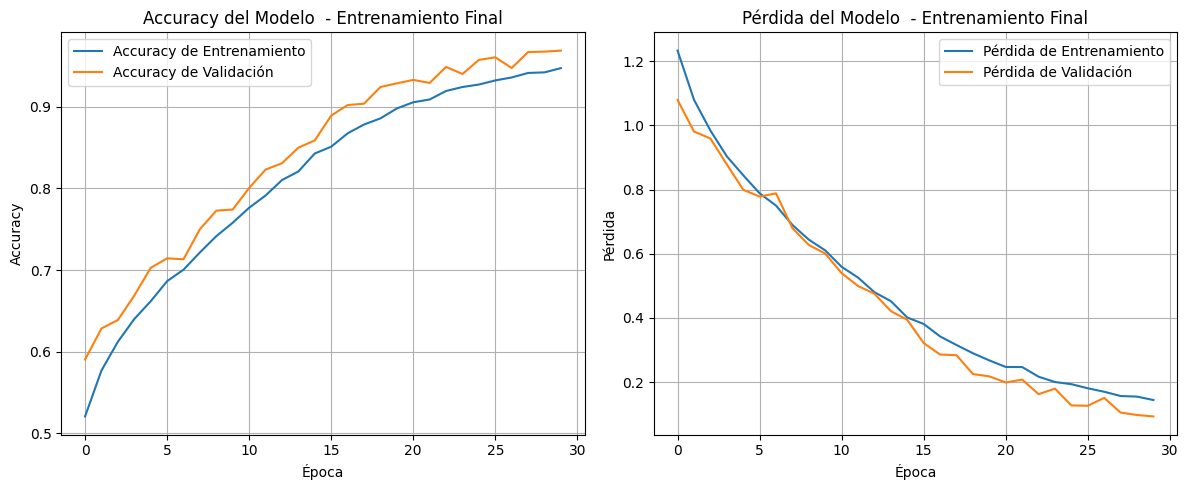

Historial completo cargado y ploteado desde archivo .npy.

--- Evaluando el mejor modelo FINAL (/content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_final_best.keras) en el conjunto de VALIDACIÓN ---
ERROR: 'validation_generator' no está definido. Asegúrate de ejecutar las celdas de preprocesamiento de datos.

--- Evaluando el mejor modelo FINAL (/content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_final_best.keras) en el conjunto de TEST ---
ERROR: 'test_generator' no está definido. Asegúrate de ejecutar las celdas de preprocesamiento de datos.


In [ ]:
# --- Celda 7: VISUALIZACIÓN DE RESULTADOS Y EVALUACIÓN FINAL (AJUSTADA PARA .NPY) ---
print("\n--- VISUALIZANDO EL HISTORIAL DE ENTRENAMIENTO Y EVALUACIÓN FINAL ---")

# Asegúrate de que estas importaciones estén en la Celda 3 o al inicio de tu notebook
# import json
# import numpy as np # Ya importado en Celda 3
# import matplotlib.pyplot as plt # Ya importado en Celda 3
# import os # Ya importado en Celda 3
# import tensorflow as tf # Ya importado en Celda 3


def plot_training_history(history_dict, title_suffix=""):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    # Verificar si 'accuracy' está en el diccionario y no está vacío
    if 'accuracy' in history_dict and history_dict['accuracy']:
        plt.plot(history_dict['accuracy'], label='Accuracy de Entrenamiento')
    if 'val_accuracy' in history_dict and history_dict['val_accuracy']:
        plt.plot(history_dict['val_accuracy'], label='Accuracy de Validación')
    plt.title(f'Accuracy del Modelo {title_suffix}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    # Verificar si 'loss' está en el diccionario y no está vacío
    if 'loss' in history_dict and history_dict['loss']:
        plt.plot(history_dict['loss'], label='Pérdida de Entrenamiento')
    if 'val_loss' in history_dict and history_dict['val_loss']:
        plt.plot(history_dict['val_loss'], label='Pérdida de Validación')
    plt.title(f'Pérdida del Modelo {title_suffix}')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Cargar y plotear el historial completo de entrenamiento (desde .npy) ---
# Usamos RUTA_HISTORY_FINAL que guarda el historial de la Fase 2 (completa)
if os.path.exists(RUTA_HISTORY_FINAL):
    try:
        loaded_full_history = np.load(RUTA_HISTORY_FINAL, allow_pickle='TRUE').item()
        plot_training_history(loaded_full_history, title_suffix=" - Entrenamiento Final")
        print("Historial completo cargado y ploteado desde archivo .npy.")
    except Exception as e:
        print(f"Error al cargar o plotear el historial completo: {e}")
        print("Advertencia: Historial de entrenamiento completo no encontrado en local. Asegúrate de que las fases de entrenamiento se hayan ejecutado y guardado.")
else:
    print(f"El archivo de historial completo no se encontró en {RUTA_HISTORY_FINAL}.")

# --- La evaluación final en conjuntos de validación/test ---
# Cargamos el modelo final (guardado en RUTA_MODELO_FINAL) para la evaluación.
if os.path.exists(RUTA_MODELO_FINAL):
    print(f"\n--- Evaluando el mejor modelo FINAL ({RUTA_MODELO_FINAL}) en el conjunto de VALIDACIÓN ---")
    try:
        best_model_final_val = tf.keras.models.load_model(RUTA_MODELO_FINAL)
        # Asegúrate de que validation_generator esté disponible desde celdas anteriores.
        loss_val, accuracy_val = best_model_final_val.evaluate(validation_generator)
        print(f"Accuracy final del mejor modelo FINAL en VALIDACIÓN: {accuracy_val:.4f}")
        print(f"Pérdida final del mejor modelo FINAL en VALIDACIÓN: {loss_val:.4f}")
    except NameError:
        print("ERROR: 'validation_generator' no está definido. Asegúrate de ejecutar las celdas de preprocesamiento de datos.")
    except Exception as e:
        print(f"Error al cargar o evaluar el modelo final en validación: {e}")
else:
    print(f"No se encontró el modelo FINAL en {RUTA_MODELO_FINAL}. Asegúrate de que se haya guardado correctamente en la Celda de Fase 2.")


if os.path.exists(RUTA_MODELO_FINAL):
    print(f"\n--- Evaluando el mejor modelo FINAL ({RUTA_MODELO_FINAL}) en el conjunto de TEST ---")
    try:
        best_model_final_test = tf.keras.models.load_model(RUTA_MODELO_FINAL)
        # Asegúrate de que test_generator esté disponible desde celdas anteriores.
        loss_test, accuracy_test = best_model_final_test.evaluate(test_generator)
        print(f"Accuracy final del mejor modelo FINAL en TEST: {accuracy_test:.4f}")
        print(f"Pérdida final del mejor modelo FINAL en TEST: {loss_test:.4f}")
    except NameError:
        print("ERROR: 'test_generator' no está definido. Asegúrate de ejecutar las celdas de preprocesamiento de datos.")
    except Exception as e:
        print(f"Error al cargar o evaluar el modelo final en test: {e}")
else:
    print("No se puede evaluar el conjunto de test sin el modelo FINAL.")

# --- La evaluación final en conjuntos de validación/test ---
# (Esto sigue asumiendo que tienes un modelo guardado en RUTA_MODELO_FASE2)
# ... El resto de tu código para evaluar el modelo ...
# if os.path.exists(RUTA_MODELO_FASE2):
#     print(f"\n--- Evaluando el mejor modelo de la Fase 2 ({RUTA_MODELO_FASE2}) en el conjunto de VALIDACIÓN ---")
#     best_model_fase2 = tf.keras.models.load_model(RUTA_MODELO_FASE2)
#     loss_val, accuracy_val = best_model_fase2.evaluate(validation_generator)
#     print(f"Accuracy final del mejor modelo de Fase 2 en VALIDACIÓN: {accuracy_val:.4f}")
#     print(f"Pérdida final del mejor modelo de Fase 2 en VALIDACIÓN: {loss_val:.4f}")
# else:
#     print(f"No se encontró el mejor modelo de la Fase 2 en {RUTA_MODELO_FASE2}. Asegúrate de que se haya guardado correctamente.")

# if os.path.exists(RUTA_MODELO_FASE2):
#     print(f"\n--- Evaluando el mejor modelo de la Fase 2 ({RUTA_MODELO_FASE2}) en el conjunto de TEST ---")
#     best_model_fase2_test = tf.keras.models.load_model(RUTA_MODELO_FASE2)
#     loss_test, accuracy_test = best_model_fase2_test.evaluate(test_generator)
#     print(f"Accuracy final del mejor modelo de Fase 2 en TEST: {accuracy_test:.4f}")
#     print(f"Pérdida final del mejor modelo de Fase 2 en TEST: {loss_test:.4f}")
# else:
#     print("No se puede evaluar el conjunto de test sin el modelo de Fase 2.")

In [ ]:
# --- Celda 8: Carga de Modelos y Función de Procesamiento ---

print("\n--- CARGANDO MODELOS Y PREPARANDO FUNCIÓN DE INFERENCIA ---")

# Inicialización de variables globales para los modelos y etiquetas
detector_caras_inf = None
clasificador_emociones_inf = None
EMOTION_LABELS_INF = None # Usaremos esta para las etiquetas de emoción finales

# --- Carga del Detector YOLO ---
# RUTA_MODELO_YOLO_FINAL está definida en la Celda 3.
try:
    detector_caras_inf = YOLO(RUTA_MODELO_YOLO_FINAL)
    print(f"Detector YOLO '{RUTA_MODELO_YOLO_FINAL}' cargado exitosamente.")
except Exception as e:
    print(f"ERROR al cargar detector YOLO: {e}")
    # Considera raise si esto es un error crítico y quieres detener la ejecución
    # raise

# --- Carga del Clasificador de Emociones ---
# Ahora usamos RUTA_MODELO_FINAL para cargar el clasificador de emociones.
try:
    clasificador_emociones_inf = tf.keras.models.load_model(RUTA_MODELO_FINAL) # <--- CAMBIO AQUÍ
    print(f"Clasificador de emociones '{RUTA_MODELO_FINAL}' cargado exitosamente.")
except Exception as e:
    print(f"ERROR al cargar clasificador de emociones: {e}")
    # raise

# --- Carga de Índices de Emociones ---
# RUTA_INDICES_EMOCIONES_FINAL y EMOTION_LABELS ya están definidos en la Celda 3.
try:
    if os.path.exists(RUTA_INDICES_EMOCIONES_FINAL):
        with open(RUTA_INDICES_EMOCIONES_FINAL, 'r') as f:
            class_indices = json.load(f)
        # Convertir claves de str a int ya que json.dump guarda las claves como str
        EMOTION_LABELS_INF = {int(v): k for k, v in class_indices.items()}
        print(f"Índices de emociones cargados: {EMOTION_LABELS_INF}")
    else:
        # Usamos EMOTION_LABELS definida en la Celda 3 como respaldo
        if 'EMOTION_LABELS' in globals(): # Verifica que EMOTION_LABELS exista globalmente
            EMOTION_LABELS_INF = EMOTION_LABELS
            print("Advertencia: No se encontraron índices de emociones guardados. Usando etiquetas predeterminadas de la Celda 3.")
        else:
            print("ERROR: Ni índices de emociones guardados ni EMOTION_LABELS predeterminadas encontradas.")
            raise NameError("Etiquetas de emoción no definidas. Deteniendo la carga.")
except Exception as e:
    print(f"ERROR al cargar índices de emociones: {e}. Usando etiquetas predeterminadas.")
    if 'EMOTION_LABELS' in globals(): # Verifica de nuevo en caso de excepción distinta a FileNotFoundError
        EMOTION_LABELS_INF = EMOTION_LABELS
    else:
        print("ERROR: EMOTION_LABELS predeterminadas tampoco están definidas.")
        raise NameError("Etiquetas de emoción no definidas. Deteniendo la carga.")

# --- Función Auxiliar: Obtener Color de Emoción (YA CORREGIDA POR TI ANTERIORMENTE) ---
def _get_emotion_color(emotion: str) -> Tuple[int, int, int]:
    """Obtener color para cada emoción (formato BGR para OpenCV)."""
    # Define tus colores preferidos en formato BGR (Azul, Verde, Rojo)
    colors = {
        'happy': (0, 255, 0),        # Verde (correctamente definido en BGR)
        'sad': (255, 0, 0),          # Azul (corregido: antes era Rojo BGR, ahora es Azul BGR)
        'angry': (0, 0, 255),        # Rojo (corregido: antes era Azul BGR, ahora es Rojo BGR)
        'fear': (128, 0, 128),       # Púrpura (correctamente definido en BGR)
        'surprise': (0, 255, 255),   # Amarillo (correctamente definido en BGR)
        'disgust': (0, 128, 0),      # Verde oscuro (correctamente definido en BGR)
        'neutral': (128, 128, 128)   # Gris (correctamente definido en BGR)
    }
    # Retorna el color correspondiente a la emoción, o blanco por defecto si no se encuentra
    return colors.get(emotion, (255, 255, 255)) # Por defecto: Blanco

# --- Función Principal: Procesamiento de Frame para Mostrar ---
def process_frame_for_display(frame):
    # IMG_WIDTH_EMO, IMG_HEIGHT_EMO y CLASES_YOLO_CARAS están definidos en Celda 3
    if detector_caras_inf is None or clasificador_emociones_inf is None or EMOTION_LABELS_INF is None:
        print("Modelos o etiquetas de emoción no cargados correctamente. La inferencia no puede continuar.")
        return frame # Retorna el frame original si los modelos no están listos

    display_frame = frame.copy()
    h, w, _ = display_frame.shape

    # Realiza la detección de caras con YOLO (confianza ajustada)
    results = detector_caras_inf(frame, conf=0.35, classes=[0], verbose=False)

    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            label_yolo = CLASES_YOLO_CARAS.get(cls, "Desconocido")

            # --- AJUSTE DEL ROI (REGIÓN DE INTERÉS) PARA LA CARA ---
            padding_x_percent = 0.15
            padding_y_percent = 0.20

            padding_x = int((x2 - x1) * padding_x_percent)
            padding_y = int((y2 - y1) * padding_y_percent)

            # Asegurar que las coordenadas no se salgan de los límites de la imagen
            x1 = max(0, x1 - padding_x)
            y1 = max(0, y1 - padding_y)
            x2 = min(w, x2 + padding_x)
            y2 = min(h, y2 + padding_y)

            # --- FIN AJUSTE DEL ROI ---

            if label_yolo == 'face': # Si detecta una cara
                face_roi = frame[y1:y2, x1:x2]

                if face_roi.shape[0] > 0 and face_roi.shape[1] > 0: # Asegurarse de que el ROI no esté vacío
                    # Redimensionar el ROI de la cara para el clasificador de emociones
                    face_roi_resized = cv2.resize(face_roi, (IMG_WIDTH_EMO, IMG_HEIGHT_EMO))

                    # Convertir a 3 canales si es necesario (ej. si la imagen es en escala de grises)
                    if len(face_roi_resized.shape) == 2:
                        face_roi_rgb = cv2.cvtColor(face_roi_resized, cv2.COLOR_GRAY2BGR)
                    else:
                        face_roi_rgb = face_roi_resized

                    # --- INICIO DEL CAMBIO CRÍTICO DE PREPROCESAMIENTO ---
                    # Añadir una dimensión de batch para el modelo de Keras
                    face_roi_batch = np.expand_dims(face_roi_rgb, axis=0)

                    # Aplicar la misma función de preprocesamiento que se usó durante el entrenamiento de EfficientNetB0
                    # ¡Esto es CRÍTICO para que el modelo entienda la entrada correctamente!
                    face_roi_preprocessed = preprocess_input(face_roi_batch) # <-- CAMBIO APLICADO AQUÍ

                    # Realizar la predicción de la emoción
                    predictions = clasificador_emociones_inf.predict(face_roi_preprocessed, verbose=0)[0] # <-- CAMBIO APLICADO AQUÍ (variable de entrada)
                    # --- FIN DEL CAMBIO CRÍTICO DE PREPROCESAMIENTO ---

                    emotion_index = np.argmax(predictions)
                    emotion_label = EMOTION_LABELS_INF.get(emotion_index, "Desconocido")
                    emotion_confidence = predictions[emotion_index] * 100

                    # --- Ajustes para el Dibujado ---
                    current_color = _get_emotion_color(emotion_label) # Obtener color basado en la emoción

                    thickness_rectangle = 3
                    cv2.rectangle(display_frame, (x1, y1), (x2, y2), current_color, thickness_rectangle)

                    font_scale = 1.0
                    thickness_text = 3

                    text = f"{emotion_label}: {emotion_confidence:.0f}%"

                    cv2.putText(display_frame, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, font_scale, current_color, thickness_text)

    return display_frame


--- CARGANDO MODELOS Y PREPARANDO FUNCIÓN DE INFERENCIA ---
Detector YOLO '/content/Proyecto_Final_Upgrade/models/yolov8n-face.pt' cargado exitosamente.
Clasificador de emociones '/content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_final_best.keras' cargado exitosamente.
Índices de emociones cargados: {0: 'angry', 1: 'disgusted', 2: 'fearful', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprised'}


In [ ]:
# --- Celda 9: Demostración con Imagen de Ejemplo (Interna del Drive) ---
print("\n--- PROCESO DE DETECCIÓN EN IMAGEN DE EJEMPLO INTERNA ---")

EXAMPLE_IMAGE_PATH = '/content/Proyecto_Final_Upgrade/test_images/grupo_personas.jpg'

def process_image_from_file(image_path):
    """
    Función para cargar y procesar una imagen desde una ruta de archivo
    y mostrar el resultado.
    """
    # Validación para evitar errores si la ruta de la imagen es incorrecta.
    if not os.path.exists(image_path):
        print(f"ERROR: La imagen de ejemplo '{image_path}' no se encontró.")
        print("Por favor, coloca una imagen de prueba en la ruta especificada o ajusta la ruta en el código.")
        return

    img = cv2.imread(image_path)
    # Asegura que la imagen sea un archivo válido.
    if img is None:
        print(f"ERROR: No se pudo cargar la imagen '{image_path}'. Verifica que es un archivo de imagen válido.")
        return

    processed_img = process_frame_for_display(img)

    # Proporciona un método de visualización que funciona en Google Colab.
    # cv2_imshow ya está disponible si google.colab.patches se importó en Celda 3.
    try:
        from google.colab.patches import cv2_imshow # Importación local si no está en Celda 3
        cv2_imshow(processed_img)
    except ImportError:
        # Fallback para entornos que no son Colab (requiere ventana GUI)
        print("Advertencia: No se pudo usar cv2_imshow (no en Colab). Mostrando con cv2.imshow (requiere entorno GUI).")
        cv2.imshow('Deteccion de Emociones en Imagen', processed_img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

# Ejecutar la función con la imagen de ejemplo.
process_image_from_file(EXAMPLE_IMAGE_PATH)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# --- Celda 11: Demostración con Imagen Externa (Subida en el Momento) ---
print("\n--- PROCESO DE DETECCIÓN EN IMAGEN EXTERNA ---")
# Mensaje informativo.
# Esta celda te permitirá subir una imagen directamente desde tu ordenador.
# Una vez ejecutada, aparecerá un botón "Elegir Archivos".

from google.colab import files # Necesario para la funcionalidad de subir archivos en Colab

def process_uploaded_image():
    """
    Define la función para manejar la subida y procesamiento de imágenes.
    """
    uploaded = files.upload() # Interfaz para seleccionar archivos desde la máquina local

    for fn in uploaded.keys(): # Itera sobre cada nombre de archivo subido.
        print(f"Usuario subió archivo: {fn}")

        # Guardar el archivo temporalmente para que `cv2.imread` pueda leerlo.
        with open(fn, 'wb') as f:
            f.write(uploaded[fn])

        img = cv2.imread(fn)
        # Validación para asegurar que la imagen es válida.
        if img is None:
            print(f"ERROR: No se pudo cargar la imagen '{fn}'. Verifica que es un archivo de imagen válido.")
            continue # Pasa al siguiente archivo si hay un problema con este.

        # Reutiliza la lógica de procesamiento para imágenes de cámaras o internas.
        # process_frame_for_display está definido en la Celda 9.
        processed_img = process_frame_for_display(img)

        # Visualiza el resultado.
        try:
            from google.colab.patches import cv2_imshow # Importación específica para Colab
            cv2_imshow(processed_img)
        except ImportError:
            # Fallback para entornos que no son Colab (requiere ventana GUI)
            print("Advertencia: No se pudo usar cv2_imshow (no en Colab). Mostrando con cv2.imshow (requiere entorno GUI).")
            cv2.imshow('Deteccion de Emociones en Imagen Subida', processed_img)
            cv2.waitKey(0)
            cv2.destroyAllWindows()

        # Eliminar el archivo temporal para limpiar el espacio de almacenamiento de Colab.
        os.remove(fn)
    print("Proceso de imagen externa finalizado.")

# Ejecutar la función para iniciar el proceso de subida.
process_uploaded_image()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
from collections import defaultdict

# Ruta base donde se encuentran las carpetas train, val, test
base_emotions_path = '/content/Proyecto_Final_Upgrade/Datos_YOLO/Emotions/'

# Diccionario para almacenar el conteo total por cada emoción en todos los splits
total_emotion_counts = defaultdict(int)

print("--- Conteo de imágenes por clase de emoción en cada split ---")

# Iterar a través de los splits (train, val, test)
for split_name in os.listdir(base_emotions_path):
    split_path = os.path.join(base_emotions_path, split_name)

    # Asegurarse de que es un directorio (train, val, test)
    if os.path.isdir(split_path):
        print(f"\nSplit: {split_name}/")
        # Iterar a través de las carpetas de emociones dentro de cada split
        for emotion_label in os.listdir(split_path):
            emotion_dir = os.path.join(split_path, emotion_label)

            # Asegurarse de que es una carpeta de emoción
            if os.path.isdir(emotion_dir):
                num_images = len([name for name in os.listdir(emotion_dir) if os.path.isfile(os.path.join(emotion_dir, name))])
                print(f"  - {emotion_label}: {num_images} imágenes")
                total_emotion_counts[emotion_label] += num_images

print("\n--- Conteo TOTAL de imágenes por clase de emoción (todos los splits combinados) ---")
# Ordenar las clases para una mejor visualización
sorted_emotion_counts = sorted(total_emotion_counts.items(), key=lambda item: item[0])
for emotion, count in sorted_emotion_counts:
    print(f"- {emotion}: {count} imágenes")

--- Conteo de imágenes por clase de emoción en cada split ---

Split: test/
  - neutral: 626 imágenes
  - surprise: 416 imágenes
  - sad: 594 imágenes
  - happy: 879 imágenes
  - angry: 491 imágenes
  - fear: 528 imágenes
  - disgust: 55 imágenes

Split: val/
  - neutral: 607 imágenes
  - surprise: 415 imágenes
  - sad: 653 imágenes
  - happy: 895 imágenes
  - angry: 467 imágenes
  - fear: 496 imágenes
  - disgust: 56 imágenes

Split: train/
  - neutral: 4965 imágenes
  - surprise: 3171 imágenes
  - sad: 4830 imágenes
  - happy: 7215 imágenes
  - angry: 3995 imágenes
  - fear: 4097 imágenes
  - disgust: 436 imágenes

--- Conteo TOTAL de imágenes por clase de emoción (todos los splits combinados) ---
- angry: 4953 imágenes
- disgust: 547 imágenes
- fear: 5121 imágenes
- happy: 8989 imágenes
- neutral: 6198 imágenes
- sad: 6077 imágenes
- surprise: 4002 imágenes


In [5]:
import tensorflow as tf
import os

# --- Configuración de path local y Rutas (de tu Celda 3 en Colab) ---
# ASEGÚRATE de que estas rutas son CORRECTAS en tu entorno de Colab.
# LOCAL_BASE_PATH es la ruta base donde tienes tus archivos en Colab/Drive.
LOCAL_BASE_PATH = "/content/Proyecto_Final_Upgrade" # O la ruta que uses en Colab
DIRECTORIO_MODELOS_PERSISTENTE = os.path.join(LOCAL_BASE_PATH, 'models')

# Ruta para el modelo .keras que ya funciona en tu Colab
RUTA_MODELO_FINAL = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'emotion_classifier_efficientnetb0_final_best.keras')

# --- NUEVA RUTA para el SavedModel ---
# El SavedModel se guardará en una CARPETA, no en un archivo .keras
RUTA_SAVED_MODEL_EMOCIONES = os.path.join(DIRECTORIO_MODELOS_PERSISTENTE, 'emotion_classifier_efficientnetb0_saved_model')

print(f"Ruta del modelo Keras a cargar en Colab: {RUTA_MODELO_FINAL}")
print(f"Ruta donde se guardará el SavedModel en Colab: {RUTA_SAVED_MODEL_EMOCIONES}")

# 1. Cargar tu modelo Keras existente (como lo haces en la Celda 8 de Colab)
try:
    clasificador_emociones_inf = tf.keras.models.load_model(RUTA_MODELO_FINAL)
    print("Clasificador de emociones cargado exitosamente en Colab (formato .keras).")
except Exception as e:
    print(f"ERROR al cargar clasificador de emociones en Colab (formato .keras): {e}")
    print("Por favor, asegúrate de que RUTA_MODELO_FINAL apunta al archivo correcto y que el modelo es válido en Colab.")
    clasificador_emociones_inf = None # Asegurarse de que sea None si falla la carga

# 2. Guardar el modelo en formato SavedModel
if clasificador_emociones_inf is not None:
    try:
        # Crea la carpeta si no existe
        os.makedirs(RUTA_SAVED_MODEL_EMOCIONES, exist_ok=True)
        # Guarda el modelo en formato SavedModel
        tf.saved_model.save(clasificador_emociones_inf, RUTA_SAVED_MODEL_EMOCIONES)
        print(f"Modelo de emociones guardado exitosamente como SavedModel en: {RUTA_SAVED_MODEL_EMOCIONES}")
    except Exception as e:
        print(f"ERROR al guardar el modelo como SavedModel en Colab: {e}")
else:
    print("No se pudo guardar el modelo como SavedModel porque no se cargó correctamente el modelo .keras inicial.")


Ruta del modelo Keras a cargar en Colab: /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_final_best.keras
Ruta donde se guardará el SavedModel en Colab: /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model
Clasificador de emociones cargado exitosamente en Colab (formato .keras).
Modelo de emociones guardado exitosamente como SavedModel en: /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model


In [6]:
    import os

    # Ruta de la carpeta que quieres comprimir
    # ASEGÚRATE de que esta ruta es CORRECTA y coincide con donde se guardó tu SavedModel
    # Según tus logs anteriores, esta debería ser la ruta correcta:
    saved_model_folder_path = '/content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model'

    # Nombre del archivo ZIP de salida
    zip_file_name = 'emotion_classifier_efficientnetb0_saved_model.zip'

    # Ruta completa donde se guardará el archivo ZIP de salida
    # Lo guardaremos en la misma carpeta padre que el SavedModel
    zip_file_path = os.path.join(os.path.dirname(saved_model_folder_path), zip_file_name)

    print(f"Comprimiendo la carpeta: {saved_model_folder_path} en {zip_file_path}")

    # Comando de terminal para comprimir la carpeta
    # El -r es para recursivo (incluir subcarpetas y sus contenidos)
    # El {saved_model_folder_path} es la carpeta que se va a comprimir
    # El {zip_file_path} es el nombre y la ruta del archivo ZIP resultante
    !zip -r {zip_file_path} {saved_model_folder_path}

Comprimiendo la carpeta: /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model en /content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model.zip
  adding: content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model/ (stored 0%)
  adding: content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model/fingerprint.pb (stored 0%)
  adding: content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model/assets/ (stored 0%)
  adding: content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model/variables/ (stored 0%)
  adding: content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: content/Proyecto_Final_Upgrade/models/emotion_classifier_efficientnetb0_saved_model/variables/variables.index (deflated 75%)
  adding: content/Proyecto_Final_Upgrade/models/emotion_